In [36]:
import numpy as np
from scipy.linalg import expm, norm
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 14})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

noiseless_trotter = [-0.98154344,  0.12240967,  0.15658802,  0.16886631,  0.17418587]
exp_ZNE_list = [-0.9348704971030127, 0.15499168378196496, 0.1587983722179112, 0.17863513967391817, 0.2277655921946963]
linear_ZNE_list = [-0.9353, 0.1625, 0.1841, 0.1839, 0.1648]
PEA_list = [-0.9057139338595162, 0.18067253769822983, 0.21467182700278528, 0.2513755353645078, 0.30217601678058964]

r_scale = 2
r_list = r_scale * np.array([1, 2, 3, 5, 17])
b_list = [1/165888, -256/89775, 6561/179200, -390625/2128896, 6975757441/6067353600]
s_list = 1 / r_list

In [33]:
exp_ZNE_extrapolated = np.vdot(b_list, exp_ZNE_list)
linear_ZNE_extrapolated = np.vdot(b_list, linear_ZNE_list)
PEA_extrapolated = np.vdot(b_list, PEA_list)
noiseless_extrapolated = np.vdot(b_list, noiseless_trotter)

t = 3.0
H = np.load('Ising_Hamiltonian.npy')
U = expm(-1j * H * t)

# spectral norm of U
# norm(U, ord=2)

# 创建一个初始态，这里以 |0...1⟩ 初始态为例
n = 5
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data
psi_t = U @ psi0
Z = np.array([[1, 0], [0, -1]])
Z_list = [np.kron(np.kron(np.eye(2**(n-i-1)), Z),np.eye(2**i)) for i in range(n)]
expectation_value = np.vdot(psi_t, Z_list[4] @ psi_t)
expectation_value

(0.17465919752149778+0j)

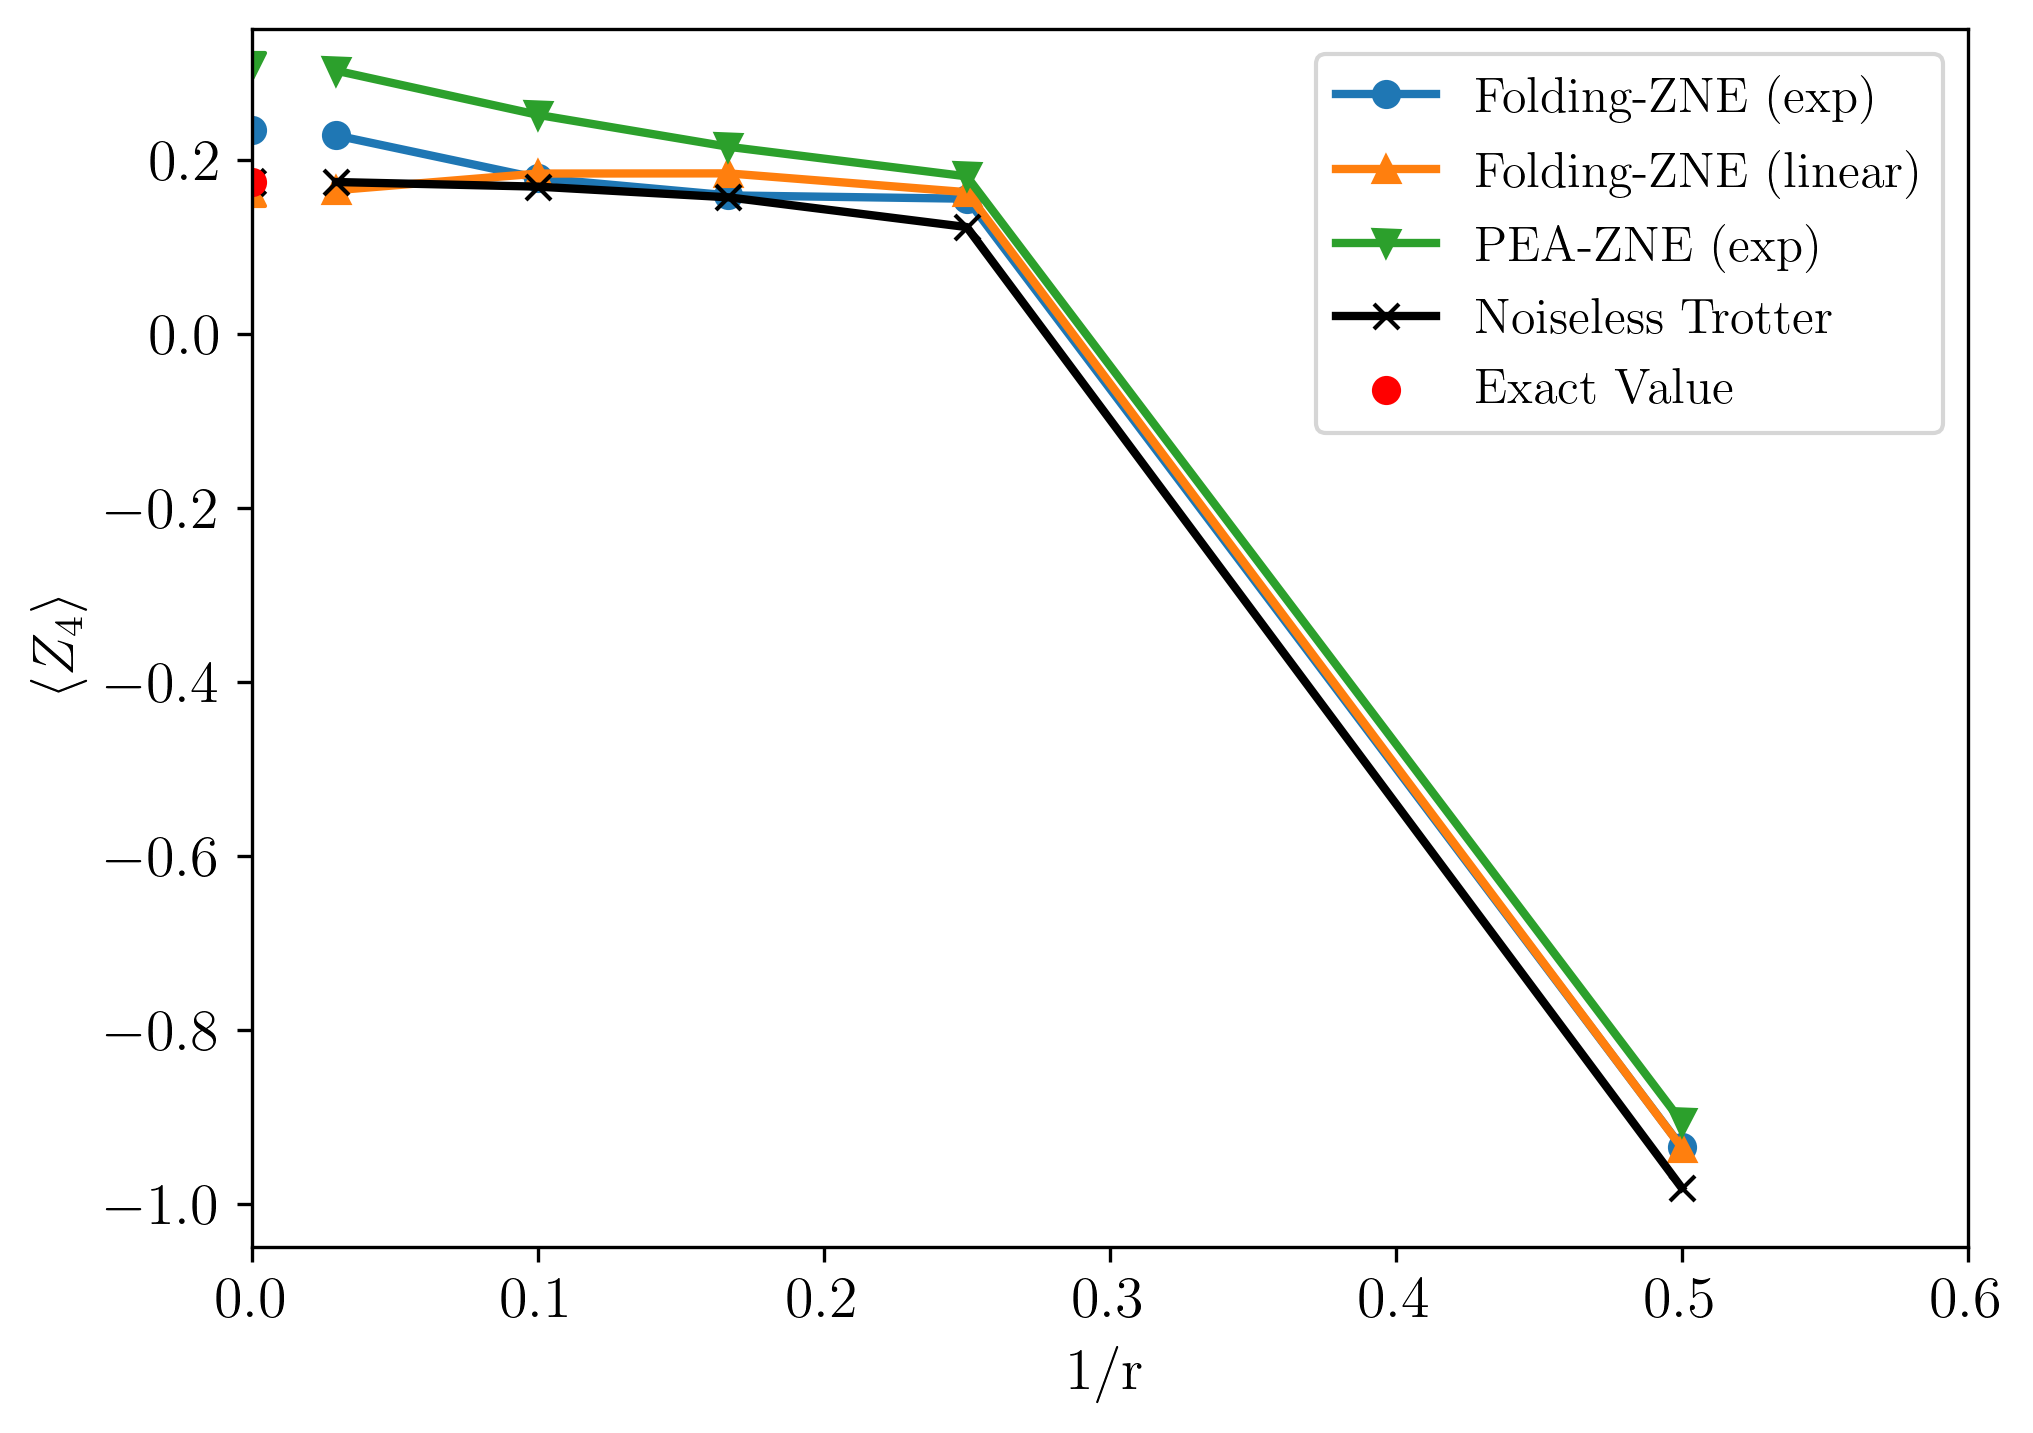

In [40]:
# Create the plot
plt.figure(figsize=(7,5), dpi=300)
plt.plot(s_list, exp_ZNE_list, marker='o', linewidth=2, label='Folding-ZNE (exp)', color = 'C0')
plt.scatter(0, exp_ZNE_extrapolated, marker='o', color='C0')

plt.plot(s_list, linear_ZNE_list, marker='^', linewidth=2, label='Folding-ZNE (linear)', color = 'C1')
plt.scatter(0, linear_ZNE_extrapolated, marker='^', color='C1')

plt.plot(s_list, PEA_list, marker='v', linewidth=2, label='PEA-ZNE (exp)', color = 'C2')
plt.scatter(0, PEA_extrapolated, marker='v', color='C2')

plt.plot(s_list, noiseless_trotter, marker='x', linewidth=2, label='Noiseless Trotter', color = 'black')
plt.scatter(0, noiseless_extrapolated, marker='x', color='black')

plt.scatter(0, expectation_value, marker='o', color='red', label='Exact Value')

plt.xlabel('1/r')
plt.ylabel(r'$\langle Z_4 \rangle$')
plt.xlim(0.0, 0.6)
plt.ylim(-1.05, 0.35)
plt.legend(loc = 'upper right', fontsize=12)
plt.tight_layout()
plt.savefig('ZNE_compare.pdf')